# Quick start tutorial for anatomical analysis
Run 2.Quickstart_anatomical.ipynb first to get the Jacabian and xfm transform file. 
To start you need:
* An anatomical T1-weighted image of each subject (``sub-ex_T1w.nii.gz``)

*Note: You can find additional details and explanations for each step in the corresponding sections of the documentation.*


## Getting setup 
Install SUITPy

`pip install SUITPy`

For detailed instructions and dependencies, see `Installation`.

In [2]:
# Import necessary packages
import os
import numpy as np
import nibabel as nib
import nilearn.plotting as npl
import matplotlib.pyplot as plt
import SUITPy as suit

## 5. Summarize regional volume with atlas ROI
While the SUIT pipeline provides voxel-wise estimates of local volume differences, 
it can also be useful to summarize these differences at the level of predefined regions. 
One approach is to inversely transform an atlas from template space to native space and then 
count the voxels in native space. 

Equivalently, the same result can be obtained by summing the detJ values within each region in template space, 
which gives an estimate of the total volume in native space. This approach is computationally more efficient.

The ``sum`` of detJ values within a region,
multiplied by the template voxel volume, gives the estimated regional
volume in mm³.

To download cerebellar atlases, see `Cerebellar Atlases` or go directly to the
[Atlas repository](https://github.com/DiedrichsenLab/cerebellar_atlases).
You may have to download it first using:

``suit.fetch_atlas('Nettekoven_2024')``

The function ``summarize_data`` then computes summary statistics inside each
atlas region and returns the results as a ``pandas.DataFrame``.




In [3]:
detJ_file = '../docs/source/tutorials/sub-ex_T1w_to-SUIT_mode-image_detJ.nii.gz'

# Summarize the jacobian 
df = suit.summarize_data(
    images = [detJ_file],
    atlas  = 'Nettekoven_2024',
    # atlas_dir="/Users/wangyaping/Documents/GitHub/cerebellar_atlases", 
    maps   = 'atl-NettekovenSym32',
    space  = 'SUIT',
    stats  = ['sum', 'mean'])

# Multiply by voxel-volume and look at result 
df['ind_vol_mm3'] = df['mean'] * df['volume']
df['volume']
# print(df[['region', 'regionname', 'vol_mm3']].head())


0      1691.0
1      7246.0
2      8023.0
3      3966.0
4      1134.0
5      2511.0
6      1093.0
7      4390.0
8     11932.0
9     11196.0
10     1889.0
11     6515.0
12    11658.0
13      737.0
14     5444.0
15      871.0
16     1667.0
17     7265.0
18     7765.0
19     3893.0
20     1119.0
21     2447.0
22     1106.0
23     4516.0
24    11726.0
25    11142.0
26     1793.0
27     6856.0
28    12039.0
29      640.0
30     5294.0
31      827.0
Name: volume, dtype: float64

## 6. check whether same when we invertransformed the atlas into subject space


In [5]:
# Calculate the region-wise volume in SUIT space by multiplying the mean jacobian determinant with the number of voxels in each region, 
# which gives us the volume of each region in SUIT space. This can be compared to the native space volume to see how much expansion or contraction occurred during normalization.

detJ_file = '../docs/source/tutorials/sub-ex_T1w_to-SUIT_mode-image_detJ.nii.gz'
df = suit.summarize_data(
    images = [detJ_file],
    atlas  = 'Nettekoven_2024',
    # atlas_dir="/Users/wangyaping/Documents/GitHub/cerebellar_atlases",
    maps   = 'atl-NettekovenSym32',
    space  = 'SUIT',
    stats  = ['sum', 'mean'])
df['ind_vol_mm3'] = df['mean'] * df['volume']

# To check whether the same when we invertransformed the atlas into subject space, 
# we can reslice the atlas to native space and compute the volume of each region in native space.
# results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
#                          mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
#                          write_inv_deformation=True)
atlas_dir=os.getenv('SUITPy_ATLAS_DIR')
atlas_file = os.path.join(atlas_dir, 'Nettekoven_2024','atl-NettekovenSym32_space-SUIT_dseg.nii')
inv_def_file = '../docs/source/tutorials/sub-ex_T1w_from-SUIT_mode-image_xfm.nii.gz'
atlas_native = suit.reslice_image(
    source_image = atlas_file,
    deformation  = inv_def_file,
    interp       = 0)
atlas_native.to_filename('../docs/source/tutorials/atl-NettekovenSym32_space-SUIT_dseg_in-sub-ex_T1w.nii.gz')
# Count voxels per region × native voxel volume
atlas_data       = atlas_native.get_fdata().astype(int)
voxel_vol_native = np.abs(np.linalg.det(atlas_native.affine[:3, :3]))
regions          = np.unique(atlas_data[atlas_data > 0])
vol_native = {int(r): np.sum(atlas_data == r) * voxel_vol_native for r in regions}
df['ind_vol_mm3_native'] = df['region'].map(vol_native)
df['diff_pct'] = (df['ind_vol_mm3'] - df['ind_vol_mm3_native']) / df['ind_vol_mm3_native'] * 100

print(df[['region', 'regionname', 'ind_vol_mm3', 'ind_vol_mm3_native', 'diff_pct']]
      .round(2)
      .sort_values('diff_pct', key=abs, ascending=False)
      .to_string(index=False))


 region regionname  ind_vol_mm3  ind_vol_mm3_native  diff_pct
      7        A3L       720.02              737.80     -2.41
     32        S5R       544.97              534.72      1.92
      1        M1L      1244.86             1260.20     -1.22
      2        M2L      5450.46             5397.07      0.99
     28        S1R      5120.89             5167.66     -0.91
     26        D3R      7476.80             7413.53      0.85
      6        A2L      1832.77             1818.17      0.80
     31        S4R      3767.91             3739.59      0.76
     17        M1R      1210.17             1219.18     -0.74
     22        A2R      1856.34             1842.78      0.74
     24        D1R      2808.01             2828.11     -0.71
     23        A3R       788.36              793.87     -0.69
     14        S3L       459.91              457.11      0.61
     12        S1L      4936.95             4965.94     -0.58
     29        S2R      8625.06             8576.98      0.56
      5 

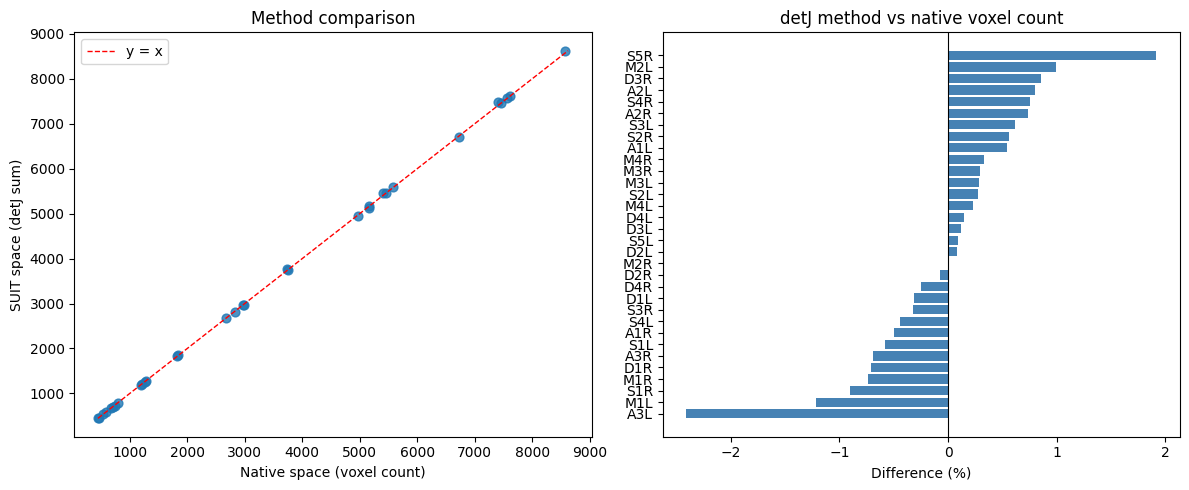

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: scatter plot - two methods agreement
ax = axes[0]
ax.scatter(df['ind_vol_mm3_native'], df['ind_vol_mm3'], s=40, alpha=0.8)
lim = [min(df[['ind_vol_mm3','ind_vol_mm3_native']].min()),
       max(df[['ind_vol_mm3','ind_vol_mm3_native']].max())]
ax.plot(lim, lim, 'r--', linewidth=1, label='y = x')
ax.set_xlabel('Native space (voxel count)')
ax.set_ylabel('SUIT space (detJ sum)')
ax.set_title('Method comparison')
ax.legend()

# Right: percentage difference per region
ax = axes[1]
df_sorted = df.sort_values('diff_pct')
ax.barh(df_sorted['regionname'], df_sorted['diff_pct'], color='steelblue')
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('Difference (%)')
ax.set_title('detJ method vs native voxel count')

plt.tight_layout()
plt.show()

## 7. check summarize_data with Jacobian in different voxel resolution

In [7]:
import os
import numpy as np
import nibabel as nib
from nilearn.image import resample_img
import SUITPy as suit

detJ_file = '../docs/source/tutorials/sub-ex_T1w_to-SUIT_mode-image_detJ.nii.gz'

# ── 1. Resample detJ to 2mm ───────────────────────────────────────────
detJ_img   = nib.load(detJ_file)
affine_2mm = detJ_img.affine.copy()
affine_2mm[:3, :3] *= 2          # double the voxel size
detJ_2mm   = resample_img(detJ_img, target_affine=affine_2mm, interpolation='continuous')
detJ_2mm_file = '../docs/source/tutorials/detJ_2mm.nii.gz'
nib.save(detJ_2mm, detJ_2mm_file)

print(f"1mm voxel vol: {np.abs(np.linalg.det(detJ_img.affine[:3,:3])):.3f} mm³")
print(f"2mm voxel vol: {np.abs(np.linalg.det(detJ_2mm.affine[:3,:3])):.3f} mm³")


1mm voxel vol: 1.000 mm³
2mm voxel vol: 8.000 mm³


/var/folders/2f/x5fxqvls6nv4ym5905k0s9vr0000gp/T/ipykernel_35011/547553717.py:13: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  detJ_2mm   = resample_img(detJ_img, target_affine=affine_2mm, interpolation='continuous')
/var/folders/2f/x5fxqvls6nv4ym5905k0s9vr0000gp/T/ipykernel_35011/547553717.py:13: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  detJ_2mm   = resample_img(detJ_img, target_affine=affine_2mm, interpolation='continuous')


In [8]:

# ── 2. Run summarize_data on both resolutions ─────────────────────────
kwargs = dict(
    atlas     = 'Nettekoven_2024',
    maps      = 'atl-NettekovenSym32',
    space     = 'SUIT',
    stats     = ['mean'])

df_2mm = suit.summarize_data(images=[detJ_2mm_file], **kwargs)
df_1mm = suit.summarize_data(images=[detJ_file],    **kwargs)

df_1mm['ind_vol_mm3'] = df_1mm['mean'] * df_1mm['volume']
df_2mm['ind_vol_mm3'] = df_2mm['mean'] * df_2mm['volume']

# ── 3. Compare ────────────────────────────────────────────────────────
import pandas as pd
compare = pd.DataFrame({
    'region'    : df_1mm['region'].values,
    'regionname': df_1mm['regionname'].values,
    'volume_1mm'   : df_1mm['volume'].values,
    'volume_2mm'   : df_2mm['volume'].values,
    'ind_vol_1mm'   : df_1mm['ind_vol_mm3'].values,
    'ind_vol_2mm'   : df_2mm['ind_vol_mm3'].values,
})
compare['diff_pct'] = (compare['ind_vol_1mm'] - compare['ind_vol_2mm']) / compare['ind_vol_1mm'] * 100

print(compare.round(2)
      .sort_values('diff_pct', key=abs, ascending=False)
      .to_string(index=False))

 region regionname  volume_1mm  volume_2mm  ind_vol_1mm  ind_vol_2mm  diff_pct
     16        S5L       871.0       920.0       580.70       613.99     -5.73
     27        D4R      1793.0      1848.0      1187.54      1237.25     -4.19
      2        M2L      7246.0      7504.0      5450.46      5648.66     -3.64
     32        S5R       827.0       800.0       544.97       527.02      3.29
     17        M1R      1667.0      1632.0      1210.17      1170.87      3.25
     14        S3L       737.0       784.0       459.91       473.62     -2.98
      7        A3L      1093.0      1056.0       720.02       700.45      2.72
     18        M2R      7265.0      7080.0      5452.52      5317.06      2.48
     22        A2R      2447.0      2392.0      1856.34      1825.04      1.69
     20        M4R      3893.0      3984.0      2680.29      2724.53     -1.65
     11        D4L      1889.0      1872.0      1277.85      1259.40      1.44
      4        M4L      3966.0      4048.0      2974